# Plot Hovmöller Diagrams for SIC, SST, SSS

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import time
import warnings
warnings.filterwarnings("ignore", module='distributed')
warnings.filterwarnings("ignore", module='UserWarning')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:46281")
client

<Client: 'tcp://127.0.0.1:46281' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [7]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

In [8]:
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(70,390))

### Isolate box along Beaufort

In [9]:
bathy_beaufort = HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth.where(HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth>0)

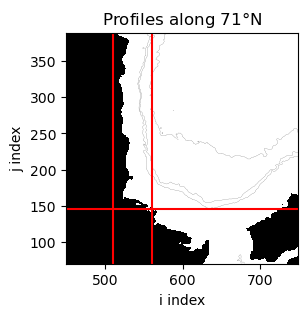

In [10]:
fig, (ax1) = plt.subplots(1,1,figsize=[3,3])
HH_land_beaufort.plot(ax=ax1,vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
bathy_beaufort.plot.contour(ax=ax1, colors='k', linewidths=0.1, levels=[500,1000,3000])
ax1.axvline(x=560,c='red')
ax1.axvline(x=510,c='red')
ax1.axhline(y=145,c='red')

ax1.set_xlabel('i index')
ax1.set_ylabel('j index')
ax1.set_title(f'Profiles along 71$\degree$N');

In [31]:
def rotate_dataarray_90ccw(da):
    """
    Rotate a 2D xarray.DataArray (i, j) 90 degrees counterclockwise.
    
    Parameters:
        da (xr.DataArray): Input data array with dims ('i', 'j').
        
    Returns:
        xr.DataArray: Rotated DataArray with dims ('i', 'j').
    """
    rotated = np.rot90(da,3,axes=[0,1])
    
    out = xr.DataArray(
        data=rotated,
        dims=('i','j'),
        coords={
            'i': da['i'],
            'j': da['j']
        },
        name=f"{da.name}"
    )
    
    return out

In [32]:
HH_land_beaufort_rot = rotate_dataarray_90ccw(HH_land_beaufort)
bathy_beaufort_rot = rotate_dataarray_90ccw(bathy_beaufort)

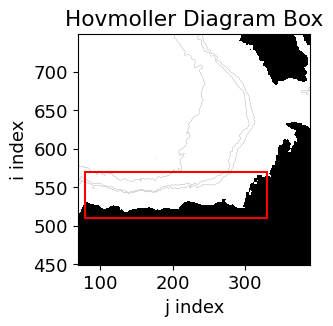

In [33]:
import matplotlib.patches as patches

# Box
x_start = 80
y_start = 510
width = 250
height = 60

fig, (ax1) = plt.subplots(1,1,figsize=[3,3])
HH_land_beaufort_rot.plot(ax=ax1, vmin=0, vmax=1, cmap='Greys_r', add_colorbar=False)
bathy_beaufort_rot.plot.contour(ax=ax1, colors='k', linewidths=0.1, levels=[500,1000,3000])

# Add red box
rect = patches.Rectangle((x_start, y_start), width, height,
                         linewidth=1.5, edgecolor='red', facecolor='none')
ax1.add_patch(rect)

ax1.set_xlabel('j index')
ax1.set_ylabel('i index')
ax1.set_title(f'Hovmoller Diagram Box')

plt.show()

## Plot Hovmöller Diagrams

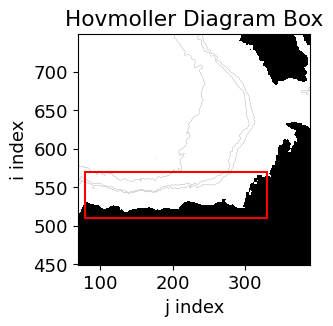

In [33]:
import matplotlib.patches as patches

# Box
x_start = 210
y_start = 520
width = 250
height = 60

fig, (ax1) = plt.subplots(1,1,figsize=[3,3])
HH_land_beaufort_rot.plot(ax=ax1, vmin=0, vmax=1, cmap='Greys_r', add_colorbar=False)
bathy_beaufort_rot.plot.contour(ax=ax1, colors='k', linewidths=0.1, levels=[500,1000,3000])

# Add red box
rect = patches.Rectangle((x_start, y_start), width, height,
                         linewidth=1.5, edgecolor='red', facecolor='none')
ax1.add_patch(rect)

ax1.set_xlabel('j index')
ax1.set_ylabel('i index')
ax1.set_title(f'Hovmoller Diagram Box')

plt.show()

In [14]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

In [15]:
sic_select = ice_da.isel(i=slice(510,568),j=slice(120,381)).where(HH_grid.mask_basin.isel(k=0,i=slice(510,568),j=slice(120,381)))
# sic_select = ice_da.isel(i=slice(510,568),j=slice(120,381)).where(HH_grid.mask_basin.isel(k=0,i=slice(510,540),j=slice(120,381)))

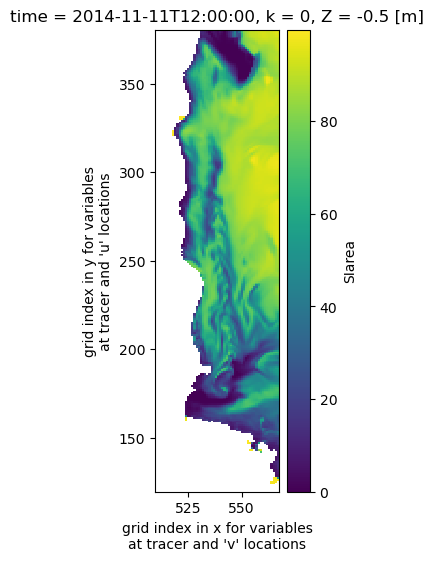

In [16]:
sic_select.isel(time=300).plot(figsize=[2,6]);

In [17]:
# take average over i coord
sic_select_mean = sic_select.mean(dim='i')

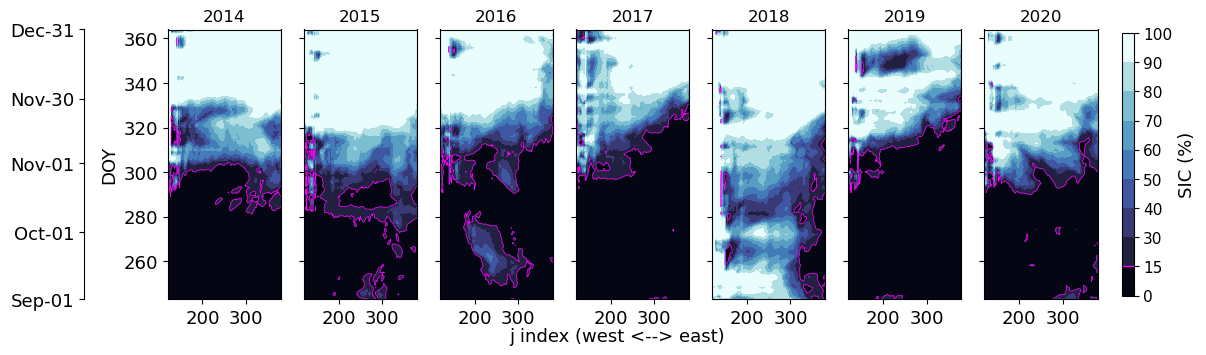

In [18]:
plt.rcParams['font.size'] = 13

# Define years and contour levels
years = range(2014, 2021)
levels = [0, 15, 30, 40, 50, 60, 70, 80, 90, 100]

# Add DOY coordinate to the dataset
sic_select_mean = sic_select_mean.assign_coords(dayofyear=sic_select.time.dt.dayofyear)

# Create figure and subplots
fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(12, 3.5), sharey=True)

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the given year
    ice_conc_year = sic_select_mean.sel(time=str(year))
    
    # Plot Hovmöller Diagram
    cbar_plot = ice_conc_year.plot.contourf(
        ax=ax, x='j', y='dayofyear', cmap=cmocean.cm.ice, levels=levels, add_colorbar=False
    )
    
    # Plot contour line for 80% sea ice concentration
    ice_conc_year.plot.contour(
        ax=ax, x='j', y='dayofyear', levels=[15], colors='magenta', linewidths=0.5
    )
    
    # Formatting
    ax.set_title(f'{year}', fontsize=12)
    # ax.set_xlim(390, 153)
    ax.set_ylim(243, 364)
    ax.set_ylabel("")
    ax.set_xlabel("")
    
# Create a secondary y-axis on the left for Month-Day labels
secax = axes[0].secondary_yaxis('left')
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")
secax.spines['left'].set_position(('outward', 60))

# Add shared y-axis label
axes[0].set_ylabel('DOY')

# Add shared x-axis label
fig.text(0.5, -0.01, 'j index (west <--> east)', ha='center', fontsize=13)

# Add a single colorbar below the entire figure, outside the subplot bounds
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.75])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical')
cbar.set_label("SIC (%)")
cbar.ax.axhline(y=15, color='magenta', linewidth=1)
cbar.ax.tick_params(labelsize=11)

plt.show()

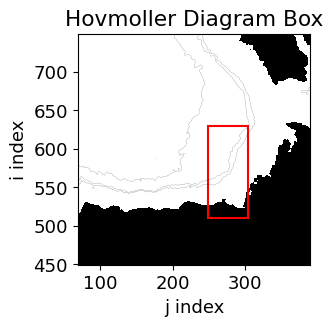

In [46]:
import matplotlib.patches as patches

# Box
x_start = 179+70
y_start = 510
width = 55
height = 120

fig, (ax1) = plt.subplots(1,1,figsize=[3,3])
HH_land_beaufort_rot.plot(ax=ax1, vmin=0, vmax=1, cmap='Greys_r', add_colorbar=False)
bathy_beaufort_rot.plot.contour(ax=ax1, colors='k', linewidths=0.1, levels=[500,1000,3000])

# Add red box
rect = patches.Rectangle((x_start, y_start), width, height,
                         linewidth=1.5, edgecolor='red', facecolor='none')
ax1.add_patch(rect)

ax1.set_xlabel('j index')
ax1.set_ylabel('i index')
ax1.set_title(f'Hovmoller Diagram Box')

plt.show()

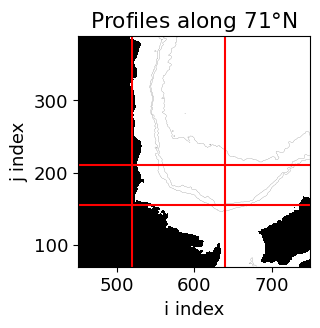

In [30]:
fig, (ax1) = plt.subplots(1,1,figsize=[3,3])
HH_land_beaufort.plot(ax=ax1,vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
bathy_beaufort.plot.contour(ax=ax1, colors='k', linewidths=0.1, levels=[500,1000,3000])
ax1.axhline(y=155,c='red')
ax1.axhline(y=210,c='red')
ax1.axvline(x=520,c='red')
ax1.axvline(x=640,c='red')

ax1.set_xlabel('i index')
ax1.set_ylabel('j index')
ax1.set_title(f'Profiles along 71$\degree$N');

In [47]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

In [48]:
sic_select = ice_da.isel(i=slice(520,640),j=slice(155,210)).where(HH_grid.mask_basin.isel(k=0,i=slice(520,640),j=slice(155,210)))

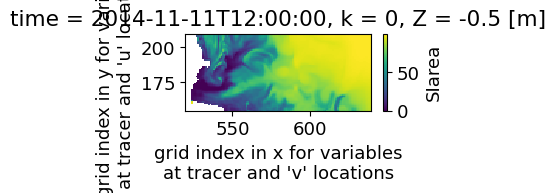

In [50]:
sic_select.isel(time=300).plot(figsize=[3,1]);

In [51]:
# take average over i coord
sic_select_mean = sic_select.mean(dim='j')

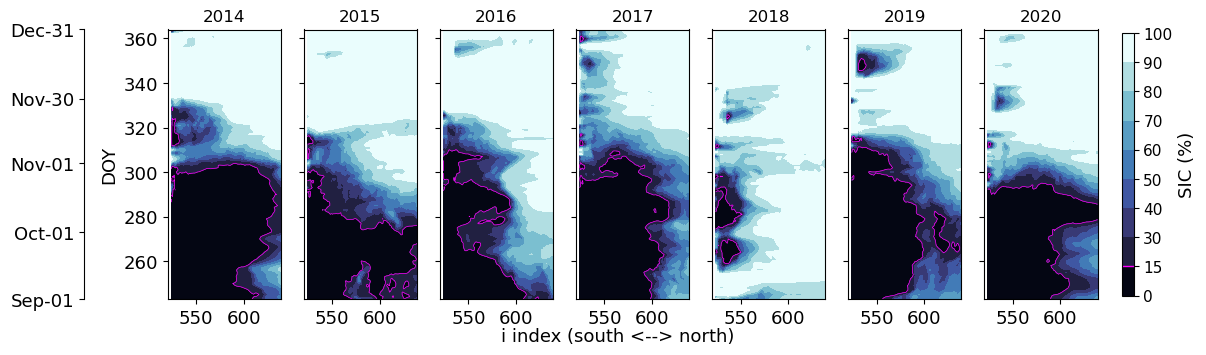

In [54]:
plt.rcParams['font.size'] = 13

# Define years and contour levels
years = range(2014, 2021)
levels = [0, 15, 30, 40, 50, 60, 70, 80, 90, 100]

# Add DOY coordinate to the dataset
sic_select_mean = sic_select_mean.assign_coords(dayofyear=sic_select.time.dt.dayofyear)

# Create figure and subplots
fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(12, 3.5), sharey=True)

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the given year
    ice_conc_year = sic_select_mean.sel(time=str(year))
    
    # Plot Hovmöller Diagram
    cbar_plot = ice_conc_year.plot.contourf(
        ax=ax, x='i', y='dayofyear', cmap=cmocean.cm.ice, levels=levels, add_colorbar=False
    )
    
    # Plot contour line for 80% sea ice concentration
    ice_conc_year.plot.contour(
        ax=ax, x='i', y='dayofyear', levels=[15], colors='magenta', linewidths=0.5
    )
    
    # Formatting
    ax.set_title(f'{year}', fontsize=12)
    # ax.set_xlim(390, 153)
    ax.set_ylim(243, 364)
    ax.set_ylabel("")
    ax.set_xlabel("")
    
# Create a secondary y-axis on the left for Month-Day labels
secax = axes[0].secondary_yaxis('left')
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")
secax.spines['left'].set_position(('outward', 60))

# Add shared y-axis label
axes[0].set_ylabel('DOY')

# Add shared x-axis label
fig.text(0.5, -0.01, 'i index (south <--> north)', ha='center', fontsize=13)

# Add a single colorbar below the entire figure, outside the subplot bounds
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.75])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical')
cbar.set_label("SIC (%)")
cbar.ax.axhline(y=15, color='magenta', linewidth=1)
cbar.ax.tick_params(labelsize=11)

plt.show()